In [1]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.8 MB/s eta 0:00:00


In [2]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.



In [3]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the PDE
def heat_pde(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)   # du/dt
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)   # d²u/dx²
    return dy_t - 0.4 * dy_xx                   # residual = 0

# 2. Define domain
geom = dde.geometry.Interval(0, 1)              # x from 0 to 1
timedomain = dde.geometry.TimeDomain(0, 1)      # t from 0 to 1
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# 3. Boundary and Initial conditions
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)
ic = dde.icbc.IC(geomtime, lambda x: np.sin(np.pi * x[:, 0:1]), lambda _, on_initial: on_initial)

# 4. Build problem
data = dde.data.TimePDE(geomtime, heat_pde, [bc, ic],
                         num_domain=2000, num_boundary=200, num_initial=200)

# 5. Build network
net = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")

# 6. Build model
model = dde.Model(data, net)

# 7. Train
model.compile("adam", lr=1e-3)
losshistory, train_state = model.train(iterations=10000)

print("Done!")

Compiling model...
'compile' took 0.322179 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7ab891226980>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7ab891226980>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7ab891226ca0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7ab891226ca0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [1.05e-01, 2.34e-02, 6.35e-01]    [1.05e-01, 2.34e-02, 6.35e-01]    []  
1000      [4.37e-04, 1.76e-04, 5.69e-05]    [4.37e-04, 1.76e-04, 5.69e-05]    []  
2000      [7.57e-05, 2.50e-05, 7.25e-06]    [7.57e-05, 2.50e-05, 7.25e-06]    []  
3000      [3.36e-05, 1.15e-05, 3.27e-06]    [3.36e-05, 1.15e-05, 3.27e-06]    []  
4000      [2.18e-05, 6.16e-06, 1.82e-06]    [2.18e-05, 6.16e-06, 1.82e-06]    []  
5000      [

L2 Relative Error: 0.027195


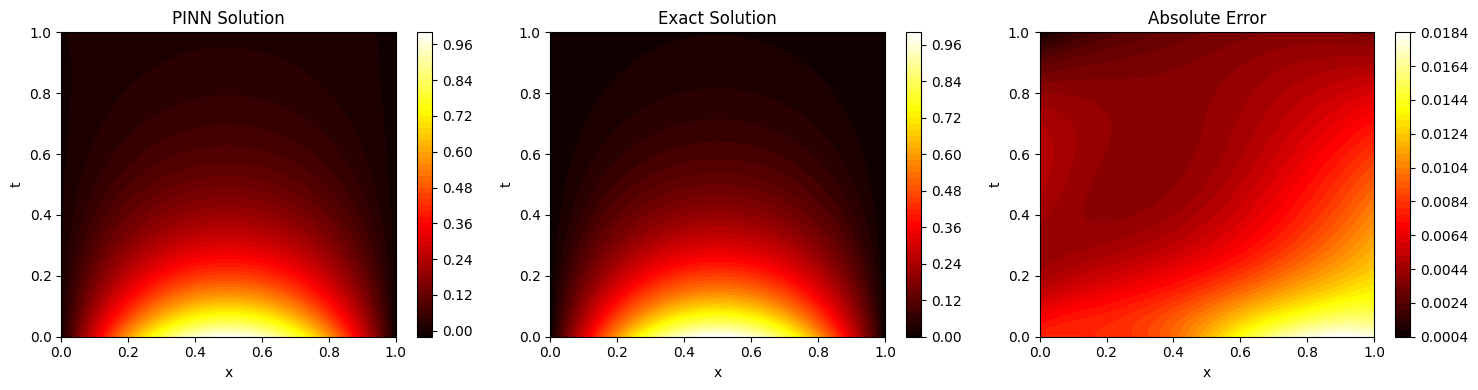

In [4]:
# Create test grid
x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)
X, T = np.meshgrid(x, t)
XT = np.column_stack([X.ravel(), T.ravel()])

# PINN prediction
u_pred = model.predict(XT).reshape(100, 100)

# Exact solution
u_exact = np.exp(-0.4 * np.pi**2 * T) * np.sin(np.pi * X)

# Absolute error
error = np.abs(u_pred - u_exact)

# L2 error
l2 = np.sqrt(np.mean((u_pred - u_exact)**2)) / np.sqrt(np.mean(u_exact**2))
print(f"L2 Relative Error: {l2:.6f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].contourf(X, T, u_pred, levels=50, cmap='hot')
axes[0].set_title('PINN Solution')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].contourf(X, T, u_exact, levels=50, cmap='hot')
axes[1].set_title('Exact Solution')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].contourf(X, T, error, levels=50, cmap='hot')
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [5]:
collocation_counts = [500, 1000, 2500, 5000, 10000]
l2_errors = []

for num in collocation_counts:
    print(f"\nTraining with {num} collocation points...")

    data = dde.data.TimePDE(geomtime, heat_pde, [bc, ic],
                             num_domain=num, num_boundary=200, num_initial=200)
    net = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
    model_c = dde.Model(data, net)
    model_c.compile("adam", lr=1e-3)
    model_c.train(iterations=10000, display_every=10000)

    u_pred = model_c.predict(XT).reshape(100, 100)
    l2 = np.sqrt(np.mean((u_pred - u_exact)**2)) / np.sqrt(np.mean(u_exact**2))
    l2_errors.append(l2)
    print(f"L2 Error: {l2:.6f}")

print("\nDone!")


Training with 500 collocation points...
Compiling model...
'compile' took 0.004041 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.03e-01, 2.33e-02, 6.35e-01]    [1.03e-01, 2.33e-02, 6.35e-01]    []  
10000     [1.18e-03, 4.90e-05, 1.01e-04]    [1.18e-03, 4.90e-05, 1.01e-04]    []  

Best model at step 10000:
  train loss: 1.33e-03
  test loss: 1.33e-03
  test metric: []

'train' took 17.299849 s

L2 Error: 0.020636

Training with 1000 collocation points...
Compiling model...
'compile' took 0.002792 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.04e-01, 2.19e-02, 6.35e-01]    [1.04e-01, 2.19e-02, 6.35e-01]    []  
10000     [5.99e-06, 1.85e-06, 1.54e-06]    [5.99e-06, 1.85e-06, 1.54e-06]    []  

Best model at step 10000:
  train loss: 9.39e-06
  test loss: 9.39e-06
  test metric: []

'train' took 17.537755 s

L2 Error: 0.003666

Tr

Step      Train loss                        Test loss                         Test metric
0         [1.05e-01, 2.06e-02, 6.35e-01]    [1.05e-01, 2.06e-02, 6.35e-01]    []  
10000     [1.46e-04, 6.99e-05, 3.57e-05]    [1.46e-04, 6.99e-05, 3.57e-05]    []  

Best model at step 10000:
  train loss: 2.52e-04
  test loss: 2.52e-04
  test metric: []

'train' took 27.814957 s



L2 Error: 0.036300

Training with 10000 collocation points...
Compiling model...
'compile' took 0.002794 s

Training model...



Step      Train loss                        Test loss                         Test metric
0         [1.06e-01, 2.23e-02, 6.35e-01]    [1.06e-01, 2.23e-02, 6.35e-01]    []  
10000     [3.74e-06, 6.93e-07, 1.81e-07]    [3.74e-06, 6.93e-07, 1.81e-07]    []  

Best model at step 10000:
  train loss: 4.61e-06
  test loss: 4.61e-06
  test metric: []

'train' took 41.848864 s



L2 Error: 0.001994

Done!


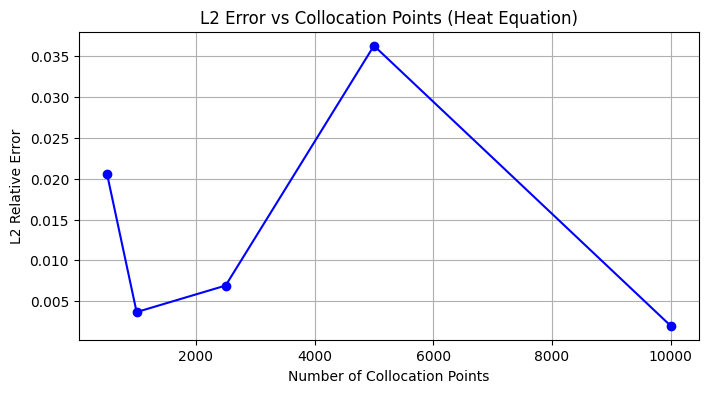

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(collocation_counts, l2_errors, marker='o', color='blue')
plt.xlabel('Number of Collocation Points')
plt.ylabel('L2 Relative Error')
plt.title('L2 Error vs Collocation Points (Heat Equation)')
plt.grid(True)
plt.show()

In [7]:
# Wave equation: u_tt = u_xx
def wave_pde(x, y):
    dy_tt = dde.grad.hessian(y, x, i=1, j=1)   # d²u/dt²
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)   # d²u/dx²
    return dy_tt - dy_xx                         # residual

# Same geometry
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# Boundary conditions: u=0 at x=0 and x=1
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)

# Initial condition: u(x,0) = sin(πx)
ic1 = dde.icbc.IC(geomtime, lambda x: np.sin(np.pi * x[:, 0:1]), lambda _, on_initial: on_initial)

# Initial velocity: du/dt (x,0) = 0
ic2 = dde.icbc.OperatorBC(
    geomtime,
    lambda x, y, _: dde.grad.jacobian(y, x, i=0, j=1),
    lambda _, on_initial: on_initial
)

# Build and train
data = dde.data.TimePDE(geomtime, wave_pde, [bc, ic1, ic2],
                         num_domain=5000, num_boundary=200, num_initial=200)
net = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
model_wave = dde.Model(data, net)
model_wave.compile("adam", lr=1e-3)
losshistory, train_state = model_wave.train(iterations=15000, display_every=5000)

print("Done!")

Compiling model...
'compile' took 0.003521 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7ab7e06a6980>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7ab7e06a6980>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7ab7e06a67a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7ab7e06a67a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                                  Test loss                                   Test metric
0         [1.56e-03, 2.61e-02, 6.35e-01, 9.91e-02]    [1.56e-03, 2.61e-02, 6.35e-01, 9.91e-02]    []  
5000      [1.18e-03, 2.96e-05, 2.68e-05, 3.16e-04]    [1.18e-03, 2.96e-05, 2.68e-05, 3.16e-04]    []  
10000     [5.21e-05, 3.08e-06, 7.58e-06, 3.46e-05]    [5.21e-05, 3.08e-06, 7.58e-06, 3.46e-05]    []  
15000     [9.30e-04, 7.88e-05, 1.12e-04, 6.41e-04]    [9.30e-04, 7.88e-05, 1.12e-04, 6.41e-04]   

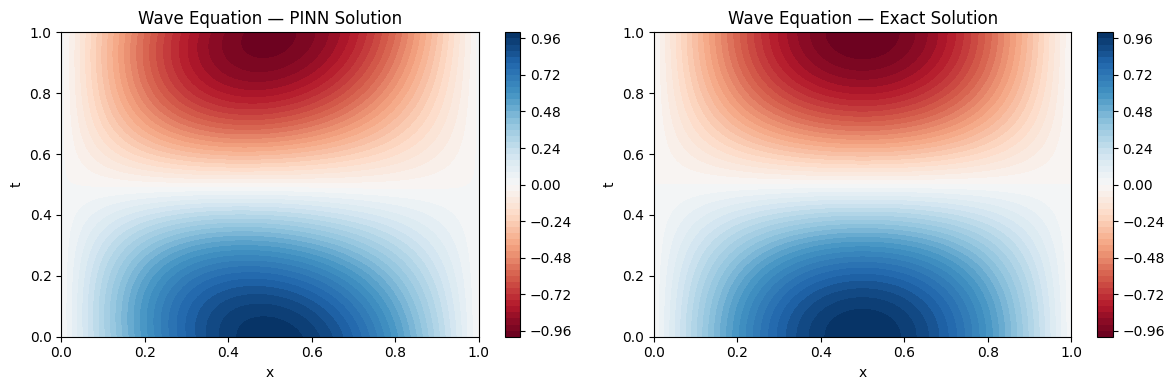

In [8]:
# Create test grid
x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)
X, T = np.meshgrid(x, t)
XT = np.column_stack([X.ravel(), T.ravel()])

# PINN prediction
u_wave_pred = model_wave.predict(XT).reshape(100, 100)

# Exact solution for wave equation
u_wave_exact = np.sin(np.pi * X) * np.cos(np.pi * T)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im1 = axes[0].contourf(X, T, u_wave_pred, levels=50, cmap='RdBu')
axes[0].set_title('Wave Equation — PINN Solution')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].contourf(X, T, u_wave_exact, levels=50, cmap='RdBu')
axes[1].set_title('Wave Equation — Exact Solution')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

Q1: Why does more collocation points help but with diminishing returns?

More points means we check the equation at more locations, giving the network better coverage of the domain. But beyond a certain point, the network's capacity becomes the bottleneck, adding more points doesn't help if the network can't learn faster.

Q2: Heat vs Wave training difficulty?

Heat equation decays smoothly, easy for the network. Wave equation oscillates, slightly harder due to spectral bias, but manageable at low frequency.

Q3: What if we used ReLU instead of tanh?

ReLU's second derivative is zero everywhere, so d²u/dx² would always be zero, making PDE loss meaningless. Tanh is smooth and infinitely differentiable, which is why PINNs always use it.